In [42]:
import pandas as pd
import numpy as np
import os

# Define the base path to the raw data
raw_dir = 'dataset/ogbn_arxiv/raw'
mapping_dir = 'dataset/ogbn_arxiv/mapping'

# 1. Load the Citation Edges (adjacency list)
# Format: source_node, target_node
edges = pd.read_csv(os.path.join(raw_dir, 'edge.csv.gz'), compression='gzip', header=None)
edges.columns = ['source', 'target']

# 2. Load the Node Features (128-dimensional embeddings)
# These are usually stored as a compressed CSV or NPY. OGB uses CSV.gz for raw.
node_feat = pd.read_csv(os.path.join(raw_dir, 'node-feat.csv.gz'), compression='gzip', header=None)

# 3. Load Node years
node_year = pd.read_csv(os.path.join(raw_dir, 'node_year.csv.gz'), compression='gzip', header=None)
node_year.columns = ['year']

# 4. Load Node to Paper ID mapping (Critical for linking to titleabs.tsv)
node_mapping = pd.read_csv(os.path.join(mapping_dir, 'nodeidx2paperid.csv.gz'), compression='gzip')

# 5. Load labels (subject categories)
labels = pd.read_csv(os.path.join(raw_dir, 'node-label.csv.gz'), compression='gzip', header=None)

print(f"Loaded {len(node_feat)} nodes")
print(f"Loaded {len(edges)} citation links")
print(f"Columns in mapping: {node_mapping.columns.tolist()}")

Loaded 169343 nodes
Loaded 1166243 citation links
Columns in mapping: ['node idx', 'paper id']


In [43]:
# load mapping from label numbers to category names
label_category_mapping = pd.read_csv(os.path.join(mapping_dir, 'labelidx2arxivcategeory.csv.gz'), compression='gzip')

# Display the unique categories
print(label_category_mapping.head())
print(f"Total categories: {len(label_category_mapping)}")

   label idx arxiv category
0          0    arxiv cs na
1          1    arxiv cs mm
2          2    arxiv cs lo
3          3    arxiv cs cy
4          4    arxiv cs cr
Total categories: 40


In [44]:
print(node_year)

        year
0       2013
1       2015
2       2014
3       2014
4       2014
...      ...
169338  2020
169339  2020
169340  2020
169341  2020
169342  2020

[169343 rows x 1 columns]


We include only papers from years 2000-2012

In [45]:
target_years = [year for year in range(2000, 2013)]
papers_in_range = node_year[node_year['year'].isin(target_years)]
print(papers_in_range.head(10))
node_indices = set(papers_in_range.index.tolist())

    year
7   2011
10  2012
13  2004
18  2009
21  2010
22  2008
26  2009
29  2011
33  2012
40  2008


In [46]:
filtered_edges = edges[edges["source"].isin(node_indices) & edges["target"].isin(node_indices)]
print(f"Total internal edges: {len(filtered_edges)}")
print(filtered_edges.head())

Total internal edges: 45697
    source  target
0   104447   13091
11   82077   19879
12   82077  147042
13   82077   35436
20   88685   11734


In [47]:
print(len(node_indices))


23421


In [48]:
import networkx as nx

nodes = list(node_indices)
G = nx.DiGraph()

G.add_nodes_from(nodes)

# Convert each edge to a tuple of (int, int)
edges_to_add = [tuple(map(int, edge)) for edge in filtered_edges.values]
G.add_edges_from(edges_to_add)


In [49]:
# Create a set for fast O(1) lookup
edge_set = set(edges_to_add)

# Find edges (u, v) where (v, u) also exists in the list
reciprocal_edges = [edge for edge in edges_to_add if (edge[1], edge[0]) in edge_set]

print(f"Total edges: {len(edges_to_add)}")
print(f"Number of reciprocal edges found: {len(reciprocal_edges)}")

if reciprocal_edges:
    print("Example reciprocal edges (source, target):")
    for i in range(min(5, len(reciprocal_edges))):
        u, v = reciprocal_edges[i]
        print(f"Edge: ({u}, {v}) | Opposite: ({v}, {u})")

Total edges: 45697
Number of reciprocal edges found: 3156
Example reciprocal edges (source, target):
Edge: (148333, 7857) | Opposite: (7857, 148333)
Edge: (83333, 10551) | Opposite: (10551, 83333)
Edge: (76903, 9122) | Opposite: (9122, 76903)
Edge: (148337, 142396) | Opposite: (142396, 148337)
Edge: (25140, 29192) | Opposite: (29192, 25140)


There are many reciprocal edges, for example:
Year 2012 <-> Year 2003


In [50]:
# Check years of reciprocal edges
for i in range(min(10, len(reciprocal_edges))):
    u, v = reciprocal_edges[i]
    year_u = node_year.loc[u, 'year']
    year_v = node_year.loc[v, 'year']
    print(f"Edge ({u}, {v}): Year {year_u} <-> Year {year_v}")

Edge (148333, 7857): Year 2012 <-> Year 2003
Edge (83333, 10551): Year 2009 <-> Year 2009
Edge (76903, 9122): Year 2006 <-> Year 2007
Edge (148337, 142396): Year 2011 <-> Year 2009
Edge (25140, 29192): Year 2010 <-> Year 2011
Edge (15861, 99171): Year 2011 <-> Year 2010
Edge (152174, 123132): Year 2008 <-> Year 2008
Edge (96623, 137697): Year 2003 <-> Year 2003
Edge (115174, 2706): Year 2007 <-> Year 2007
Edge (115174, 135871): Year 2007 <-> Year 2007


In [51]:
for i in range(7):
    src, tgt = edges_to_add[i]
    print(f"{papers_in_range.loc[src, 'year']}, {papers_in_range.loc[tgt, 'year']}")

2011, 2008
2011, 2010
2011, 2011
2011, 2006
2012, 2011
2012, 2012
2012, 2012


Removing single nodes in weakly connected components (they are useless):

In [52]:
nodes_for_removal = []
for comp in nx.weakly_connected_components(G):
        if len(comp) == 1:
            for node in comp:
                nodes_for_removal.append(node)

G.remove_nodes_from(nodes_for_removal)

## Random Networks Generation and Comparison

First we describe our network with relevant general information


In [67]:
import random

def describe_network_directed(G: nx.DiGraph):
    # Calculate approximate average shortest path lengths
    G_undirected = G.to_undirected()

    largest_cc = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G_undirected.subgraph(largest_cc)

    sampled_nodes = random.sample(list(G_lcc.nodes()), min(500, len(G_lcc)))

    all_distances = [
        dist
        for node in sampled_nodes
        for dist in nx.single_source_shortest_path_length(G_lcc, node).values()
        if dist > 0
    ]

    approx_aspl = sum(all_distances) / len(all_distances)


    max_comp = len(largest_cc)

    # To get a dictionary of node: in_degree
    in_degrees = dict(G.in_degree())

    # Average in deg
    avg_in = sum(in_degrees.values()) / len(G)

    df = pd.DataFrame({"Nodes": [G.number_of_nodes()],
                       "Edges": [G.number_of_edges()],
                       "Average In/Out Degree": [avg_in],
                       "Weakly Connected Components": [nx.number_weakly_connected_components(G)],
                       "Average Clustering Coefficient": [nx.average_clustering(G)],
                       "Largest Connected Component": [max_comp],
                       "Average Shortest Path": [approx_aspl]
                       })
    return df

describe_network_directed(G)

,Nodes,Edges,Average In/Out Degree,Weakly Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,45697,2.227492,965,0.135714,16874,10.235118


In [68]:
def describe_network_undirected(G: nx.Graph):
    
    # Get Largest Connected Component
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc)

    # Calculate approximate average shortest path lengths
    sampled_nodes = random.sample(list(G_lcc.nodes()), min(500, len(G_lcc)))
    all_distances = [
        dist
        for node in sampled_nodes
        for dist in nx.single_source_shortest_path_length(G_lcc, node).values()
        if dist > 0
    ]
    approx_aspl = sum(all_distances) / len(all_distances) if all_distances else 0

    # Average degree
    avg_deg = sum(dict(G.degree()).values()) / len(G)

    df = pd.DataFrame({
        "Nodes": [G.number_of_nodes()],
        "Edges": [G.number_of_edges()],
        "Average Degree": [avg_deg],
        "Connected Components": [nx.number_connected_components(G)],
        "Average Clustering Coefficient": [nx.average_clustering(G)],
        "Largest Connected Component": [len(largest_cc)],
        "Average Shortest Path": [approx_aspl]
    })
    return df

We generate three random networks:
- Watts-Strogatz
- Erdos-Renyi
- Barabasi-Albert

In [70]:
G_undir = G.to_undirected()
v = G_undir.number_of_nodes()
e = G_undir.number_of_edges()
erdos = nx.gnm_random_graph(v, e)
barabasi = nx.barabasi_albert_graph(v, round(e/v))
watts = nx.connected_watts_strogatz_graph(v, round(2*e/v), 0.1)


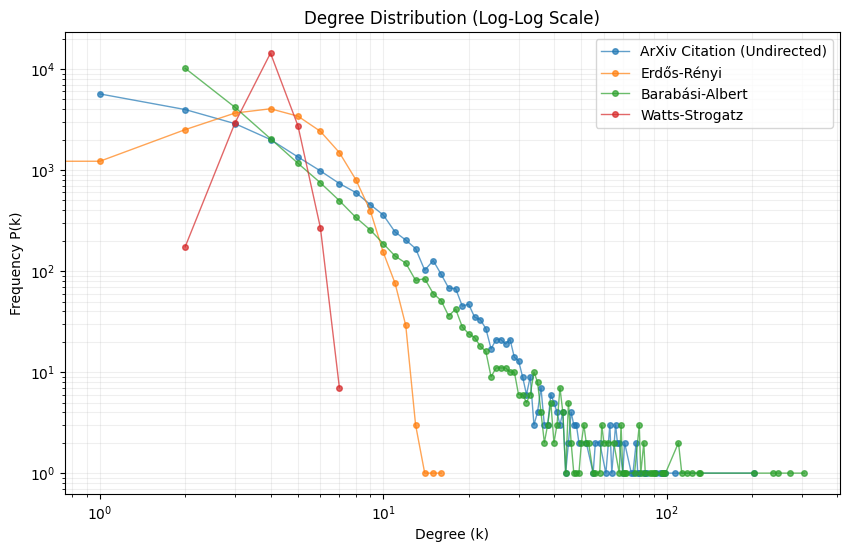

In [76]:
import matplotlib.pyplot as plt
import collections

def plot_degree_distribution(graphs, labels):
    plt.figure(figsize=(10, 6))
    
    for G_plot, label in zip(graphs, labels):
        # Get degrees
        degrees = [d for n, d in G_plot.degree()]
        
        # Count frequencies
        degree_counts = collections.Counter(degrees)
        x, y = zip(*sorted(degree_counts.items()))
        
        # Plot on log-log scale with markers and a connecting line
        plt.loglog(x, y, marker='o', markersize=4, linestyle='-', linewidth=1, label=label, alpha=0.7)

    plt.title("Degree Distribution (Log-Log Scale)")
    plt.xlabel("Degree (k)")
    plt.ylabel("Frequency P(k)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

# List of graphs and their labels
graphs = [G_undir, erdos, barabasi, watts]
labels = ["ArXiv Citation (Undirected)", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

plot_degree_distribution(graphs, labels)

In [71]:
describe_network_undirected(watts)

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,41030,4.0,1,0.374497,20515,13.786685


In [72]:
describe_network_undirected(barabasi)

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,41026,3.99961,1,0.002624,20515,5.274111


In [73]:
describe_network_undirected(erdos)

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,44119,4.301146,285,0.000114,20221,6.922709
